# Issue #3 — Clean Data and Construct Liquidity Features

Build a standardized roll panel with volume shares, OI shares, and liquidity migration metrics for each ZN quarterly roll.


In [1]:
import pandas as pd
import numpy as np
import os

ohlcv = pd.read_parquet('../data/raw/zn_ohlcv_daily.parquet')
oi    = pd.read_parquet('../data/raw/zn_open_interest.parquet')
rolls = pd.read_parquet('../data/raw/zn_roll_pairs.parquet')

ohlcv['date'] = pd.to_datetime(ohlcv['date'])
oi['date']    = pd.to_datetime(oi['date'])
rolls['fnd']  = pd.to_datetime(rolls['fnd'])

print(f'OHLCV: {len(ohlcv):,} rows | OI: {len(oi):,} rows | Rolls: {len(rolls)}')


OHLCV: 7,916 rows | OI: 5,334 rows | Rolls: 28


## 1. Build business-day calendar and compute days-to-FND


In [2]:
# Get all trading dates from the OHLCV data
bdays = sorted(ohlcv['date'].unique())
bday_index = {d: i for i, d in enumerate(bdays)}


## 2. For each roll, extract front/next volume and OI in a ±25 bday window


In [3]:
WINDOW_BEFORE = 25  # business days before FND
WINDOW_AFTER  = 5   # business days after FND

panels = []

for _, roll in rolls.iterrows():
    front, nxt, fnd = roll['front'], roll['next'], roll['fnd']
    fnd_ts = pd.Timestamp(fnd)

    # Find the nearest bday to FND
    fnd_idx = None
    for j, d in enumerate(bdays):
        if d >= fnd_ts:
            fnd_idx = j
            break
    if fnd_idx is None:
        continue

    # Window of business days
    start_idx = max(0, fnd_idx - WINDOW_BEFORE)
    end_idx   = min(len(bdays) - 1, fnd_idx + WINDOW_AFTER)
    window_dates = bdays[start_idx:end_idx + 1]

    # Front contract volume & OI
    front_vol = ohlcv[ohlcv['symbol'] == front].set_index('date')['volume']
    next_vol  = ohlcv[ohlcv['symbol'] == nxt].set_index('date')['volume']
    front_oi  = oi[oi['symbol'] == front].set_index('date')['open_interest']
    next_oi   = oi[oi['symbol'] == nxt].set_index('date')['open_interest']

    # Calendar spread volume
    spread_sym = f'{front}-{nxt}'
    spread_vol = ohlcv[ohlcv['symbol'] == spread_sym].set_index('date')['volume']

    for d in window_dates:
        bdays_to_fnd = -(fnd_idx - list(bdays).index(d))  # negative = before FND
        fv = front_vol.get(d, 0)
        nv = next_vol.get(d, 0)
        fo = front_oi.get(d, np.nan)
        no = next_oi.get(d, np.nan)
        sv = spread_vol.get(d, 0)
        total_vol = fv + nv
        total_oi  = fo + no if pd.notna(fo) and pd.notna(no) else np.nan

        panels.append({
            'roll_id': f'{front}->{nxt}',
            'front': front, 'next': nxt,
            'date': d,
            'bdays_to_fnd': bdays_to_fnd,
            'front_volume': fv, 'next_volume': nv,
            'total_volume': total_vol,
            'next_volume_share': nv / total_vol if total_vol > 0 else np.nan,
            'front_oi': fo, 'next_oi': no,
            'total_oi': total_oi,
            'next_oi_share': no / total_oi if pd.notna(total_oi) and total_oi > 0 else np.nan,
            'spread_volume': sv,
        })

panel = pd.DataFrame(panels)
print(f'Roll panel: {len(panel):,} rows across {panel["roll_id"].nunique()} rolls')
panel.head(10)


Roll panel: 837 rows across 27 rolls


,roll_id,front,next,date,bdays_to_fnd,front_volume,next_volume,total_volume,next_volume_share,front_oi,next_oi,total_oi,next_oi_share,spread_volume
0,ZNH0->ZNM0,ZNH0,ZNM0,2020-01-30,-25,2535625,634,2536259,0.000250,3803706.0,99244.0,3902950.0,0.025428,29640
1,ZNH0->ZNM0,ZNH0,ZNM0,2020-01-31,-24,2466911,1076,2467987,0.000436,3832439.0,120691.0,3953130.0,0.030530,27875
2,ZNH0->ZNM0,ZNH0,ZNM0,2020-02-02,-23,46012,84,46096,0.001822,3889130.0,142146.0,4031276.0,0.035261,101
3,ZNH0->ZNM0,ZNH0,ZNM0,2020-02-03,-22,2185444,663,2186107,0.000303,3879566.0,142146.0,4021712.0,0.035345,13305
4,ZNH0->ZNM0,ZNH0,ZNM0,2020-02-04,-21,2113255,2765,2116020,0.001307,3909460.0,152276.0,4061736.0,0.037490,10403
5,ZNH0->ZNM0,ZNH0,ZNM0,2020-02-05,-20,2434357,3705,2438062,0.001520,3914020.0,160272.0,4074292.0,0.039337,14775
6,ZNH0->ZNM0,ZNH0,ZNM0,2020-02-06,-19,1714739,1612,1716351,0.000939,3916830.0,171394.0,4088224.0,0.041924,16474
7,ZNH0->ZNM0,ZNH0,ZNM0,2020-02-07,-18,2189639,3582,2193221,0.001633,3916825.0,184109.0,4100934.0,0.044894,14847
8,ZNH0->ZNM0,ZNH0,ZNM0,2020-02-09,-17,69406,375,69781,0.005374,3920458.0,184155.0,4104613.0,0.044865,413
9,ZNH0->ZNM0,ZNH0,ZNM0,2020-02-10,-16,1536085,4585,1540670,0.002976,3917498.0,183872.0,4101370.0,0.044832,17508


## 3. Identify volume-based crossover date for each roll


In [4]:
crossovers = []
for roll_id, grp in panel.groupby('roll_id'):
    grp = grp.sort_values('date')
    cross = grp[grp['next_volume_share'] > 0.5]
    if len(cross) > 0:
        first_cross = cross.iloc[0]
        crossovers.append({
            'roll_id': roll_id,
            'crossover_date': first_cross['date'],
            'crossover_bdays_to_fnd': first_cross['bdays_to_fnd'],
        })

cross_df = pd.DataFrame(crossovers)
print(f'Crossovers identified: {len(cross_df)} / {panel["roll_id"].nunique()} rolls')
cross_df


Crossovers identified: 27 / 27 rolls


,roll_id,crossover_date,crossover_bdays_to_fnd
0,ZNH0->ZNM0,2020-02-27,-1
1,ZNH1->ZNM1,2021-02-25,-1
2,ZNH2->ZNM2,2022-02-25,-2
3,ZNH3->ZNM3,2023-02-26,-2
4,ZNH4->ZNM4,2024-02-28,-1
5,ZNH5->ZNM5,2025-02-26,-2
6,ZNH6->ZNM6,2026-02-25,-2
7,ZNM0->ZNU0,2020-05-28,-1
8,ZNM1->ZNU1,2021-05-27,-3
9,ZNM2->ZNU2,2022-05-27,-3


## 4. Summary statistics


In [5]:
if len(cross_df) > 0:
    stats = cross_df['crossover_bdays_to_fnd'].describe()
    print('Volume crossover timing (business days to FND):')
    display(pd.DataFrame(stats).T)


Volume crossover timing (business days to FND):


,count,mean,std,min,25%,50%,75%,max
crossover_bdays_to_fnd,27.0,-2.037037,0.587137,-3.0,-2.0,-2.0,-2.0,-1.0


## 5. Save processed panel


In [6]:
os.makedirs('../data/processed', exist_ok=True)
panel.to_parquet('../data/processed/zn_roll_panel.parquet', index=False)
cross_df.to_parquet('../data/processed/zn_crossovers.parquet', index=False)

print('Saved to data/processed/:')
for f in os.listdir('../data/processed'):
    size = os.path.getsize(f'../data/processed/{f}') / 1e6
    print(f'  {f}: {size:.1f} MB')


Saved to data/processed/:
  zn_roll_panel.parquet: 0.1 MB
  zn_crossovers.parquet: 0.0 MB


## 6. Visualize liquidity migration


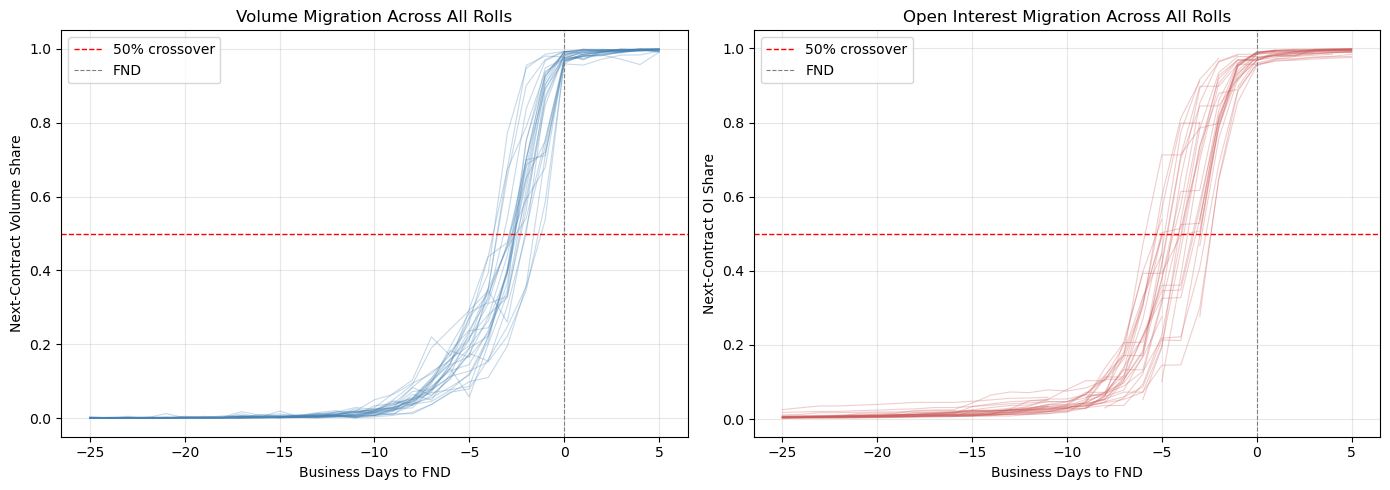

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot all rolls: next volume share vs bdays to FND
ax = axes[0]
for roll_id, grp in panel.groupby('roll_id'):
    ax.plot(grp['bdays_to_fnd'], grp['next_volume_share'], alpha=0.3, lw=0.8, color='steelblue')
ax.axhline(0.5, ls='--', color='red', lw=1, label='50% crossover')
ax.axvline(0, ls='--', color='gray', lw=0.8, label='FND')
ax.set_xlabel('Business Days to FND')
ax.set_ylabel('Next-Contract Volume Share')
ax.set_title('Volume Migration Across All Rolls')
ax.legend()
ax.grid(alpha=0.3)

# Plot all rolls: next OI share
ax = axes[1]
for roll_id, grp in panel.groupby('roll_id'):
    ax.plot(grp['bdays_to_fnd'], grp['next_oi_share'], alpha=0.3, lw=0.8, color='indianred')
ax.axhline(0.5, ls='--', color='red', lw=1, label='50% crossover')
ax.axvline(0, ls='--', color='gray', lw=0.8, label='FND')
ax.set_xlabel('Business Days to FND')
ax.set_ylabel('Next-Contract OI Share')
ax.set_title('Open Interest Migration Across All Rolls')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
